# Framework 2: SS Embedding (Linear Probe)
Multi-round AL on CIFAR-10 — linear classifier on frozen SimCLR embeddings.  
Reproduces paper's Figure 5a.

In [1]:
import sys, os, time, pickle
sys.path.append('..')
import numpy as np
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from src.representations import load_encoder, extract_embeddings
from src.evaluation import run_al_rounds

In [2]:
RESULTS_FILE = './fw2_ss_embedding_results.pkl'
LOAD_SAVED = os.path.exists(RESULTS_FILE)

if not LOAD_SAVED:
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
    trainloader = DataLoader(trainset, batch_size=256, shuffle=False, num_workers=2)
    testloader = DataLoader(testset, batch_size=256, shuffle=False, num_workers=2)

    encoder = load_encoder('./simclr_encoder_500ep.pth')
    embeddings, labels = extract_embeddings(encoder, trainloader)
    test_embeddings, test_labels = extract_embeddings(encoder, testloader)
    print(f"Embeddings: {embeddings.shape}")
else:
    print(f"Loading saved results from {RESULTS_FILE}")

Embeddings: (50000, 512)


In [3]:
if LOAD_SAVED:
    with open(RESULTS_FILE, 'rb') as f:
        results = pickle.load(f)
else:
    strategies = ['random', 'uncertainty', 'margin', 'entropy', 'coreset', 'badge', 'bald', 'dbal', 'typiclust']
    results = {}
    for s in strategies:
        t0 = time.time()
        print(f'Running {s}...', flush=True)
        results[s] = run_al_rounds(
            embeddings, labels, test_embeddings, test_labels,
            strategy=s, budget_per_round=10, n_rounds=5, n_reps=5,
            framework='ss_embedding'
        )
        elapsed = time.time() - t0
        print(f'  {elapsed:.1f}s | mean={np.round(results[s]["mean"]*100, 1)}%')

    with open(RESULTS_FILE, 'wb') as f:
        pickle.dump(results, f)
    print('Results saved.')

Running random...


  1.9s | mean=[39.7 56.4 64.6 72.  74.9]%
Running uncertainty...


  5.0s | mean=[44.2 55.8 58.6 62.8 70.2]%
Running margin...


  5.1s | mean=[44.2 60.1 68.2 78.  82.4]%
Running entropy...


  5.2s | mean=[44.2 61.9 63.5 65.6 69.6]%
Running coreset...


  28.7s | mean=[50.6 65.1 73.  76.4 76.3]%
Running badge...


  540.3s | mean=[44.2 61.4 70.1 73.  78.1]%
Running bald...


  5.7s | mean=[44.2 54.8 57.7 59.9 61.9]%
Running dbal...


  5.3s | mean=[44.2 47.1 50.7 52.8 56.9]%
Running typiclust...


  411.2s | mean=[51.9 76.9 78.2 81.6 80.8]%
Results saved.


=== SS Embedding (Linear Probe) ===
Strategy          B=10    B=20    B=30    B=40    B=50  
----------------------------------------------------------------------
random             39.7%   56.4%   64.6%   72.0%   74.9%
uncertainty        44.2%   55.8%   58.6%   62.8%   70.2%
margin             44.2%   60.1%   68.2%   78.0%   82.4%
entropy            44.2%   61.9%   63.5%   65.6%   69.6%
coreset            50.6%   65.1%   73.0%   76.4%   76.3%
badge              44.2%   61.4%   70.1%   73.0%   78.1%
bald               44.2%   54.8%   57.7%   59.9%   61.9%
dbal               44.2%   47.1%   50.7%   52.8%   56.9%
typiclust          51.9%   76.9%   78.2%   81.6%   80.8%


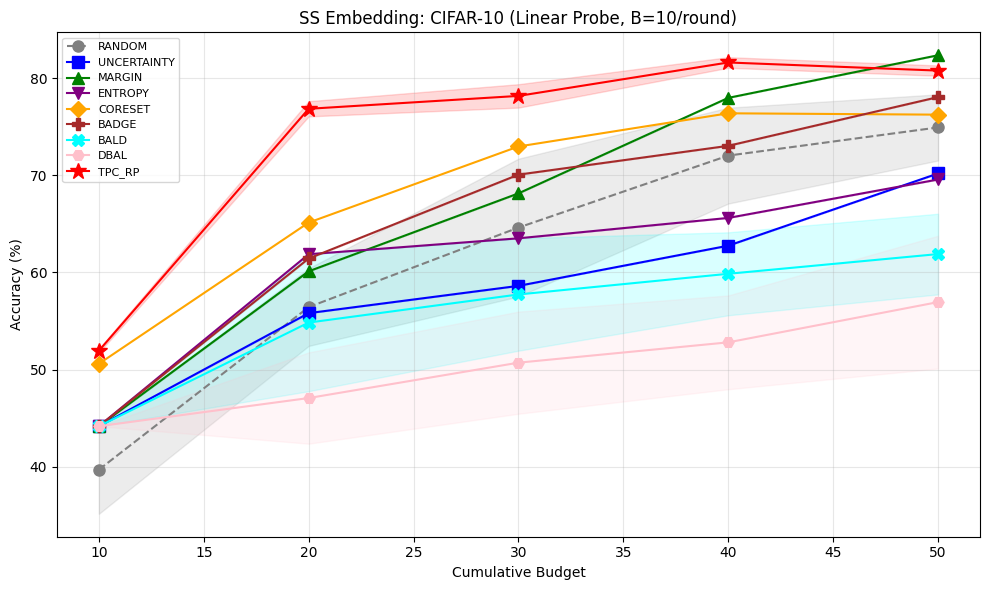

In [4]:
# Summary and plot
print("=== SS Embedding (Linear Probe) ===")
print(f"{'Strategy':<15} ", end="")
for b in results['random']['budgets']:
    print(f"  B={b:<4}", end="")
print()
print("-" * 70)
for s in results:
    print(f"{s:<15} ", end="")
    for acc in results[s]['mean']:
        print(f"  {acc*100:5.1f}%", end="")
    print()

fig, ax = plt.subplots(figsize=(10, 6))
styles = {
    'random': {'color': 'gray', 'ls': '--', 'marker': 'o'},
    'uncertainty': {'color': 'blue', 'ls': '-', 'marker': 's'},
    'margin': {'color': 'green', 'ls': '-', 'marker': '^'},
    'entropy': {'color': 'purple', 'ls': '-', 'marker': 'v'},
    'coreset': {'color': 'orange', 'ls': '-', 'marker': 'D'},
    'badge': {'color': 'brown', 'ls': '-', 'marker': 'P'},
    'bald': {'color': 'cyan', 'ls': '-', 'marker': 'X'},
    'dbal': {'color': 'pink', 'ls': '-', 'marker': 'H'},
    'typiclust': {'color': 'red', 'ls': '-', 'marker': '*', 'markersize': 12},
}
for s, r in results.items():
    st = styles[s]
    label = 'TPC_RP' if s == 'typiclust' else s.upper()
    ax.plot(r['budgets'], r['mean']*100, label=label, color=st['color'],
            linestyle=st['ls'], marker=st['marker'], markersize=st.get('markersize', 8))
    if r['std'].max() > 0:
        ax.fill_between(r['budgets'], (r['mean']-r['std'])*100, (r['mean']+r['std'])*100,
                        alpha=0.15, color=st['color'])
ax.set_xlabel('Cumulative Budget')
ax.set_ylabel('Accuracy (%)')
ax.set_title('SS Embedding: CIFAR-10 (Linear Probe, B=10/round)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../report/figures/fw2_ss_embedding.png', dpi=300, bbox_inches='tight')
plt.show()